In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('fashion-mnist_train.csv')

In [3]:
df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.isna().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [5]:
x_train= df.iloc[: , 1:]
y_train= df.iloc[:, 0]

In [6]:
x_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,1,2,0,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
x_train_scaled =x_train/255.0

In [8]:
import torch
from torch import nn

In [11]:
X_train_tensor = torch.tensor(x_train_scaled.values , dtype= torch.float32)
Y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [12]:
class MnistClassifier(nn.Module):
        def __init__(self):
                super(MnistClassifier, self).__init__()
                self.linear1=nn.Linear(784,128)
                self.relu = nn.ReLU()
                self.linear2 = nn.Linear(128, 10)
        
        def forward(self, x):
               return self.linear2(self.relu(self.linear1(x)))

In [13]:
model = MnistClassifier()
loss_nn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters() , lr = 0.01)

In [14]:
print(Y_train_tensor.shape)

torch.Size([60000])


In [15]:
losses=[]
for i in range(1000):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = loss_nn(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (i+1) % 10 == 0:
        print(f"Epoch {i + 1}: loss = {loss.item():.4f}")

Epoch 10: loss = 2.2549
Epoch 20: loss = 2.2072
Epoch 30: loss = 2.1616
Epoch 40: loss = 2.1166
Epoch 50: loss = 2.0717
Epoch 60: loss = 2.0260
Epoch 70: loss = 1.9794
Epoch 80: loss = 1.9318
Epoch 90: loss = 1.8835
Epoch 100: loss = 1.8348
Epoch 110: loss = 1.7861
Epoch 120: loss = 1.7378
Epoch 130: loss = 1.6904
Epoch 140: loss = 1.6442
Epoch 150: loss = 1.5997
Epoch 160: loss = 1.5571
Epoch 170: loss = 1.5165
Epoch 180: loss = 1.4780
Epoch 190: loss = 1.4415
Epoch 200: loss = 1.4071
Epoch 210: loss = 1.3746
Epoch 220: loss = 1.3439
Epoch 230: loss = 1.3150
Epoch 240: loss = 1.2878
Epoch 250: loss = 1.2621
Epoch 260: loss = 1.2379
Epoch 270: loss = 1.2150
Epoch 280: loss = 1.1935
Epoch 290: loss = 1.1732
Epoch 300: loss = 1.1539
Epoch 310: loss = 1.1358
Epoch 320: loss = 1.1186
Epoch 330: loss = 1.1024
Epoch 340: loss = 1.0870
Epoch 350: loss = 1.0724
Epoch 360: loss = 1.0586
Epoch 370: loss = 1.0455
Epoch 380: loss = 1.0330
Epoch 390: loss = 1.0211
Epoch 400: loss = 1.0097
Epoch 410

In [16]:
df2 = pd.read_csv('fashion-mnist_test.csv')

In [17]:
x_test = df2.iloc[:, 1:]
y_test = df2.iloc[:, 0]

In [18]:
x_test = x_test / 255.0

In [19]:
X_test_tensor = torch.tensor(x_test.values , dtype=torch.float32)
Y_test_tensor = torch.tensor(y_test.values , dtype=torch.float32)

In [20]:
with torch.no_grad():
    y_pred=model(X_test_tensor)
    y_pred_classes=torch.argmax(y_pred,dim=1)
y_pred_np=y_pred_classes.numpy()
y_test_np=Y_test_tensor.numpy()

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import label_binarize

In [22]:
accuracy = accuracy_score(y_test_np , y_pred_np)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7468


In [23]:
precesion = precision_score(y_test_np , y_pred_np , average ='macro')
recall = recall_score(y_test_np , y_pred_np , average = 'macro')
F1_score = f1_score(y_test_np , y_pred_np , average = 'macro')
print(f"Precision: {precesion}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")
cm=confusion_matrix(y_test_np,y_pred_np)
print(cm)

Precision: 0.7468973688541916
Recall: 0.7468000000000001
F1 Score: <function f1_score at 0x00000206D5BF9620>
[[779  10  12 105   5   0  60   1  26   2]
 [  6 931  19  31   7   0   5   0   0   1]
 [ 13   2 638  10 225   0  90   0  22   0]
 [ 43  16   5 870  24   0  39   0   3   0]
 [  1   6 140  71 731   0  45   0   6   0]
 [  3   0   0   3   0 567   1 278  17 131]
 [236   7 143  63 269   1 244   0  37   0]
 [  0   0   0   0   0  20   0 863   0 117]
 [  4   1   7  16   4   2  26  14 924   2]
 [  0   0   0   0   0   5   0  74   0 921]]


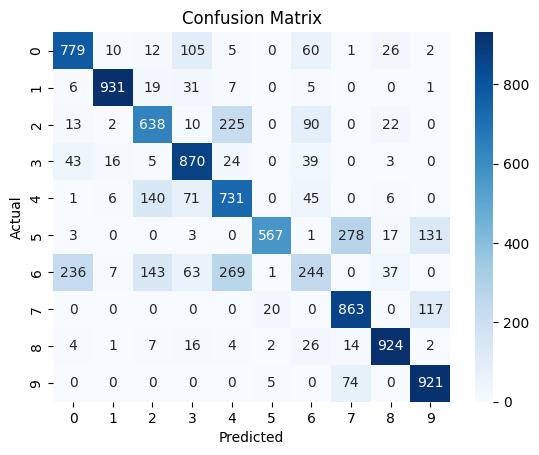

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
print(classification_report(y_pred_np , y_test_np))

              precision    recall  f1-score   support

           0       0.78      0.72      0.75      1085
           1       0.93      0.96      0.94       973
           2       0.64      0.66      0.65       964
           3       0.87      0.74      0.80      1169
           4       0.73      0.58      0.65      1265
           5       0.57      0.95      0.71       595
           6       0.24      0.48      0.32       510
           7       0.86      0.70      0.77      1230
           8       0.92      0.89      0.91      1035
           9       0.92      0.78      0.85      1174

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.74     10000
weighted avg       0.79      0.75      0.76     10000



In [26]:
from sklearn.preprocessing import label_binarize

In [27]:
y_test_bin = label_binarize(y_test_np , classes = [0,1,2,3,4,5,6,7,8,9])

In [28]:
model.eval()

with torch.no_grad():
    y_scores = torch.softmax(model(X_test_tensor), dim=1).numpy()
print(y_scores)

[[7.7731603e-01 3.1026022e-04 9.7910650e-03 ... 8.6048982e-07
  2.0881938e-03 2.0917543e-05]
 [2.0113720e-03 9.6064329e-01 4.8749027e-04 ... 4.9767928e-05
  2.3980765e-05 5.1341223e-05]
 [4.1753918e-02 1.0128718e-02 5.1791519e-01 ... 4.6876203e-03
  2.6611319e-02 1.3055396e-02]
 ...
 [5.6238579e-05 1.7025212e-06 1.5095203e-03 ... 1.6161995e-03
  9.7505659e-01 6.2931451e-04]
 [2.8723033e-02 2.7327875e-05 1.6655213e-01 ... 1.1579548e-04
  4.0802735e-01 2.7537197e-03]
 [5.3608116e-02 1.6186064e-03 3.5239235e-01 ... 3.3579699e-06
  2.8016302e-03 4.6457928e-05]]


In [29]:
from sklearn.metrics import roc_curve , auc

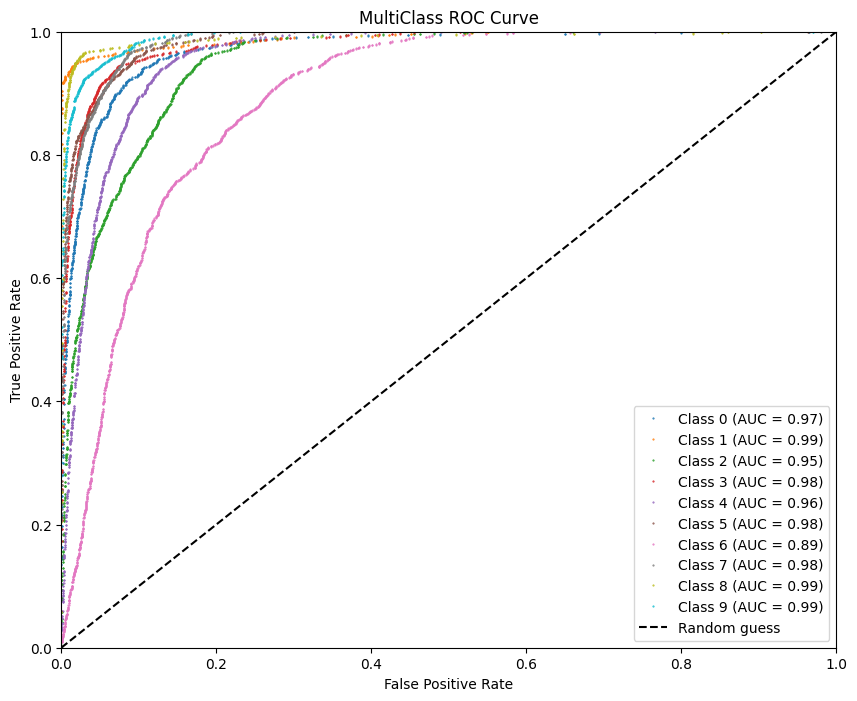

In [31]:
n_classes=y_test_bin.shape[1]
plt.figure(figsize=(10,8))
for i in range(n_classes):
    fpr, tpr,_ =roc_curve(y_test_bin[:,i] , y_scores[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr,marker ='.',linestyle='None',markersize=1, label=f'Class {i} (AUC = { roc_auc:.2f})')
plt.plot([0,1] ,[0,1] , 'k--' , label ='Random guess')
plt.xlim([0.0 , 1.0])
plt.ylim([0.0 , 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MultiClass ROC Curve')
plt.legend(loc = 'lower right')
plt.show()